## Scorecard Performance Summary

### Key Results

- Logistic Regression AUC: 0.7412
- KS Statistic: 0.3618
- XGBoost AUC: 0.7390

### Risk Band Default Rates

| Risk Band | Default Rate |
|------------|--------------|
| High Risk | 10.0% |
| Medium Risk | 2.2% |
| Low Risk | 0.0% |

### Business Insights

- Scorecard successfully separates customer risk groups
- Higher scores correspond to lower default probability
- Logistic Regression slightly outperformed XGBoost
- Score distribution appears stable and well-calibrated

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
train_score = pd.read_csv('/content/customer_credit_scores.csv')

test_score = pd.read_csv('/content/customer_credit_scores.csv')

We artificially shift scores downward.

Why?

to simulate worsening customer quality

In [3]:
production_score = test_score.copy()

In [4]:
np.random.seed(42)

production_score['score'] = (
    production_score['score'] -
    np.random.normal(20, 10, len(production_score))
)

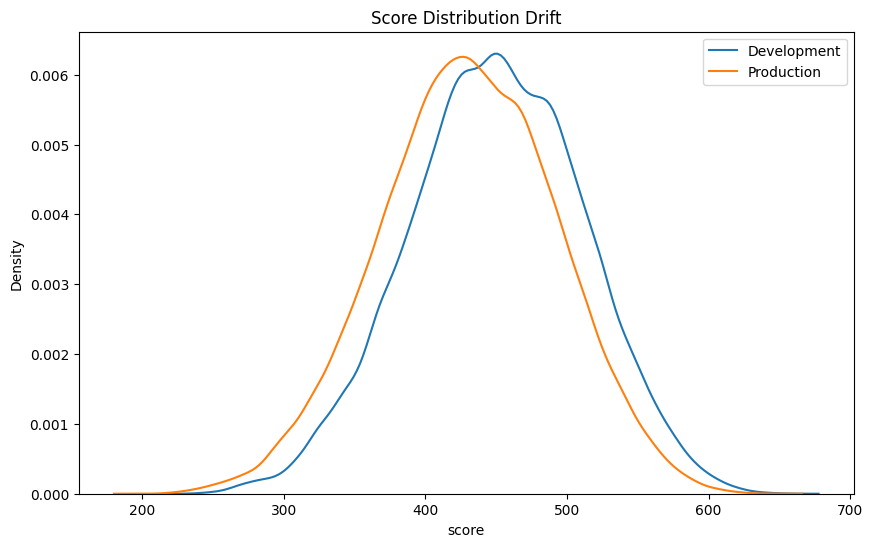

In [5]:
plt.figure(figsize=(10,6))

sns.kdeplot(
    train_score['score'],
    label='Development'
)

sns.kdeplot(
    production_score['score'],
    label='Production'
)

plt.title("Score Distribution Drift")

plt.legend()

plt.show()

If production curve shifts:



*  risk profile changed
*  model monitoring alert needed




In [6]:
def calculate_psi(expected, actual, buckets=10):

    breakpoints = np.arange(
        0,
        buckets + 1
    ) / buckets

    breakpoints = np.quantile(
        expected,
        breakpoints
    )

    expected_bins = pd.cut(
        expected,
        breakpoints,
        include_lowest=True
    )

    actual_bins = pd.cut(
        actual,
        breakpoints,
        include_lowest=True
    )

    expected_perc = (
        expected_bins.value_counts(normalize=True)
        .sort_index()
    )

    actual_perc = (
        actual_bins.value_counts(normalize=True)
        .sort_index()
    )

    psi = np.sum(
        (actual_perc - expected_perc)
        *
        np.log(
            actual_perc / expected_perc
        )
    )

    return psi

In [7]:
psi_value = calculate_psi(
    train_score['score'],
    production_score['score']
)

print("PSI:", round(psi_value, 4))

PSI: 0.0934


In [8]:
if psi_value < 0.1:
    print("Population Stable")

elif psi_value < 0.25:
    print("Moderate Population Shift")

else:
    print("Significant Population Drift")

Population Stable


In [13]:
#development distribution
train_band_dist = (
    train_score['RISK_BAND']
    .value_counts(normalize=True)
)

In [14]:
#production Distribution

production_band_dist = (
    production_score['RISK_BAND']
    .value_counts(normalize=True)
)

In [15]:
comparison = pd.DataFrame({
    'Development': train_band_dist,
    'Production': production_band_dist
})

comparison

,Development,Production
RISK_BAND,,
High Risk,0.787771,0.787771
Medium Risk,0.212197,0.212197
Low Risk,0.000033,0.000033


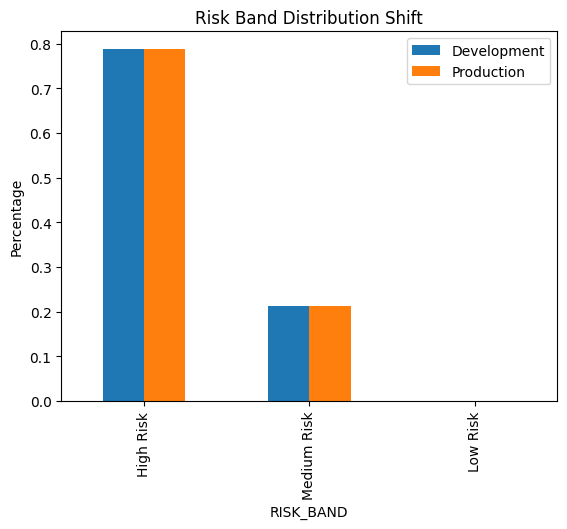

In [16]:
comparison.plot(
    kind='bar'
)

plt.title("Risk Band Distribution Shift")

plt.ylabel("Percentage")

plt.show()

In [17]:
monitoring_summary = pd.DataFrame({

    'Metric': [
        'AUC',
        'KS',
        'PSI'
    ],

    'Value': [
        0.7412,
        0.3618,
        round(psi_value, 4)
    ]
})

monitoring_summary

,Metric,Value
0,AUC,0.7412
1,KS,0.3618
2,PSI,0.0934


In [18]:
monitoring_summary.to_csv(
    '/content/model_monitoring_report.csv',
    index=False
)